# 01 — Data Exploration\n
\n
Placeholder notebook for initial OpenContrails data exploration.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)

NumPy: 2.5.3


Conserver les données hors du repository Git, dans un dossier local data/raw/, lui-même ignoré par .gitignore.

In [2]:
def find_project_root(start: Path) -> Path:
    """Localise la racine du repo indépendamment du cwd du kernel Jupyter."""
    markers = ("requirements.txt", ".git")
    start = start.resolve()

    # Cas standard : cwd = racine du repo, ou cwd = notebooks/ (cwd du kernel
    # réglé sur le dossier du notebook, comportement par défaut de Jupyter).
    for candidate in (start, *start.parents):
        if any((candidate / marker).exists() for marker in markers):
            return candidate

    # Cas où le kernel démarre depuis le dossier parent du repo (ex. le
    # dossier utilisateur), avec le repo comme sous-dossier direct.
    fallback = start / "Contrail-detection"
    if any((fallback / marker).exists() for marker in markers):
        return fallback

    raise FileNotFoundError(
        f"Racine du projet introuvable à partir de {start}. Définissez PROJECT_ROOT manuellement."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "Data" / "Raw" / "opencontrails_mini_sample"

print("Project root :", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root : C:\Users\roche\Contrail-detection
Data directory: C:\Users\roche\Contrail-detection\Data\Raw\opencontrails_mini_sample


première vraie cellule d’exploration

In [3]:
TRAIN_DIR = DATA_DIR / "train"

print("Train directory:", TRAIN_DIR)
print("Train directory exists:", TRAIN_DIR.exists())

record_dirs = sorted([p for p in TRAIN_DIR.iterdir() if p.is_dir()])

print("Nombre de records disponibles :", len(record_dirs))

record_dir = record_dirs[0]
print("Premier record :", record_dir.name)

for file in sorted(record_dir.iterdir()):
    print(file.name)

Train directory: C:\Users\roche\Contrail-detection\Data\Raw\opencontrails_mini_sample\train
Train directory exists: True
Nombre de records disponibles : 6
Premier record : 1000216489776414077
band_08.npy
band_09.npy
band_10.npy
band_11.npy
band_12.npy
band_13.npy
band_14.npy
band_15.npy
band_16.npy
human_individual_masks.npy
human_pixel_masks.npy


In [4]:
band_13 = np.load(record_dir / "band_13.npy")
mask = np.load(record_dir / "human_pixel_masks.npy")
individual_masks = np.load(record_dir / "human_individual_masks.npy")

print("band_13 shape:", band_13.shape)
print("ground truth shape:", mask.shape)
print("individual masks shape:", individual_masks.shape)

band_13 shape: (256, 256, 8)
ground truth shape: (256, 256, 1)
individual masks shape: (256, 256, 1, 4)


première visualisation temporelle

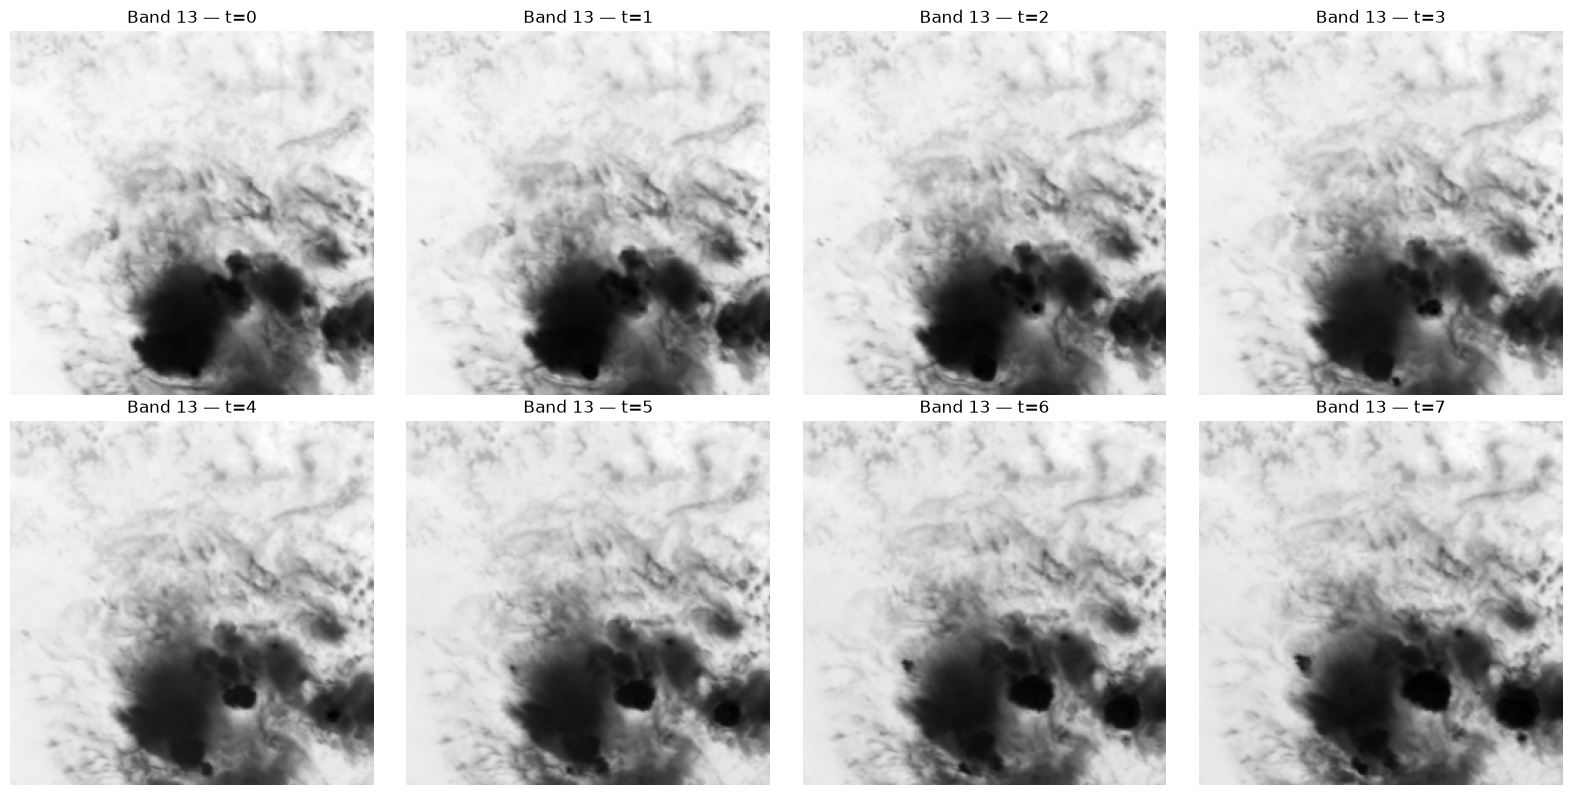

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for t, ax in enumerate(axes.flat):
    ax.imshow(band_13[:, :, t], cmap="gray")
    ax.set_title(f"Band 13 — t={t}")
    ax.axis("off")

plt.tight_layout()
plt.show()

affichage

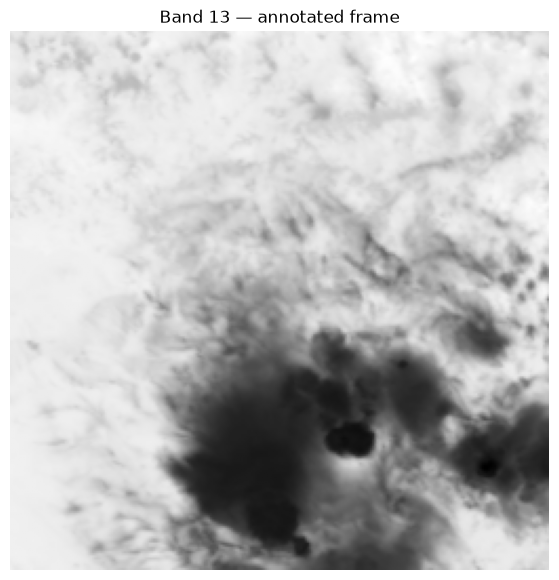

In [6]:
TARGET_FRAME = 4

plt.figure(figsize=(7, 7))
plt.imshow(band_13[:, :, TARGET_FRAME], cmap="gray")
plt.title("Band 13 — annotated frame")
plt.axis("off")
plt.show()

comparer au masque

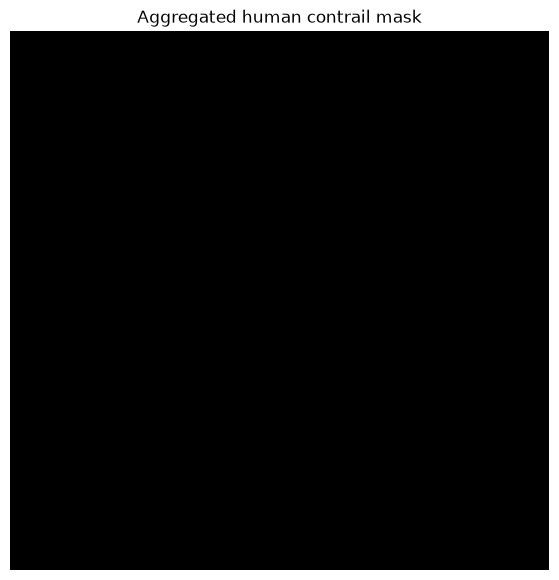

In [7]:
plt.figure(figsize=(7, 7))
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Aggregated human contrail mask")
plt.axis("off")
plt.show()

## Vérification des dimensions et statistiques sur plusieurs records

Le premier record inspecté plus haut (`1000216489776414077`) ne contient aucun pixel positif — son masque est vide. Avant d'aller plus loin, on vérifie que toutes les bandes ont bien la même forme sur l'ensemble des records `train`, et on regarde la distribution du déséquilibre de classe (fraction de pixels contrail) d'un record à l'autre.

In [8]:
import pandas as pd

BAND_IDS = list(range(8, 17))


def record_stats(record_dir: Path) -> dict:
    shapes = {f"band_{b:02d}": np.load(record_dir / f"band_{b:02d}.npy").shape for b in BAND_IDS}
    bands_consistent = len(set(shapes.values())) == 1

    mask = np.load(record_dir / "human_pixel_masks.npy")
    individual = np.load(record_dir / "human_individual_masks.npy")

    return {
        "record_id": record_dir.name,
        "band_shape": next(iter(shapes.values())) if bands_consistent else shapes,
        "bands_consistent": bands_consistent,
        "mask_shape": mask.shape,
        "n_annotators": individual.shape[-1],
        "positive_frac": float(mask.mean()),
        "n_positive_px": int(mask.sum()),
    }


stats_df = pd.DataFrame(record_stats(r) for r in record_dirs)
stats_df

,record_id,band_shape,bands_consistent,mask_shape,n_annotators,positive_frac,n_positive_px
0,1000216489776414077,"(256, 256, 8)",True,"(256, 256, 1)",4,0.000000,0
1,1000603527582775543,"(256, 256, 8)",True,"(256, 256, 1)",4,0.085129,5579
2,1000660467359258186,"(256, 256, 8)",True,"(256, 256, 1)",4,0.010284,674
3,100071707854144929,"(256, 256, 8)",True,"(256, 256, 1)",6,0.000000,0
4,1000823728928031783,"(256, 256, 8)",True,"(256, 256, 1)",4,0.005630,369
5,1000934780200790693,"(256, 256, 8)",True,"(256, 256, 1)",4,0.000000,0


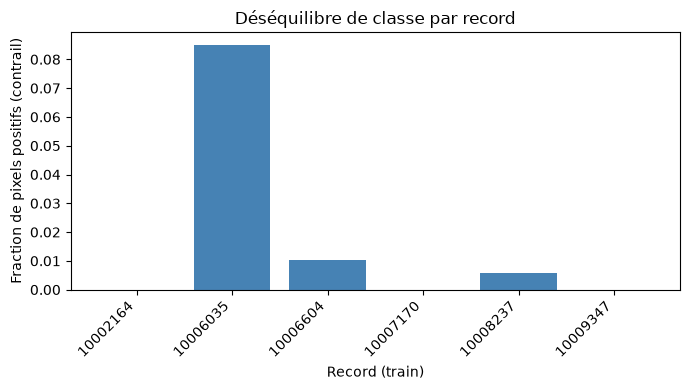

Bandes cohérentes sur tous les records : True

Statistiques sur positive_frac :
count    6.000000
mean     0.016841
std      0.033713
min      0.000000
25%      0.000000
50%      0.002815
75%      0.009121
max      0.085129
Name: positive_frac, dtype: float64


In [9]:
plt.figure(figsize=(7, 4))
plt.bar(range(len(stats_df)), stats_df["positive_frac"], color="steelblue")
plt.xticks(range(len(stats_df)), [rid[:8] for rid in stats_df["record_id"]], rotation=45, ha="right")
plt.ylabel("Fraction de pixels positifs (contrail)")
plt.xlabel("Record (train)")
plt.title("Déséquilibre de classe par record")
plt.tight_layout()
plt.show()

print("Bandes cohérentes sur tous les records :", bool(stats_df["bands_consistent"].all()))
print("\nStatistiques sur positive_frac :")
print(stats_df["positive_frac"].describe())

## Annotations individuelles — désaccord entre annotateurs

`human_individual_masks.npy` contient un masque binaire par annotateur (4 à 6 selon le record), uniquement pour la frame annotée. `human_pixel_masks.npy` est leur agrégat par vote majoritaire. On travaille ici sur un record qui contient effectivement des contrails (`positive_frac > 0`), pour que la comparaison soit informative.

In [10]:
# Record avec la plus grande fraction de pixels positifs parmi ceux disponibles
disagreement_record_id = stats_df.loc[stats_df["positive_frac"].idxmax(), "record_id"]
disagreement_record_dir = TRAIN_DIR / disagreement_record_id

mask_agg = np.load(disagreement_record_dir / "human_pixel_masks.npy").squeeze()
individual_masks = np.load(disagreement_record_dir / "human_individual_masks.npy").squeeze(axis=2)  # (H, W, n_annotateurs)

n_annotators = individual_masks.shape[-1]
print("Record utilisé :", disagreement_record_id)
print("Nombre d'annotateurs :", n_annotators)
print("Fraction de pixels positifs (masque agrégé) :", mask_agg.mean())

Record utilisé : 1000603527582775543
Nombre d'annotateurs : 4
Fraction de pixels positifs (masque agrégé) : 0.0851287841796875


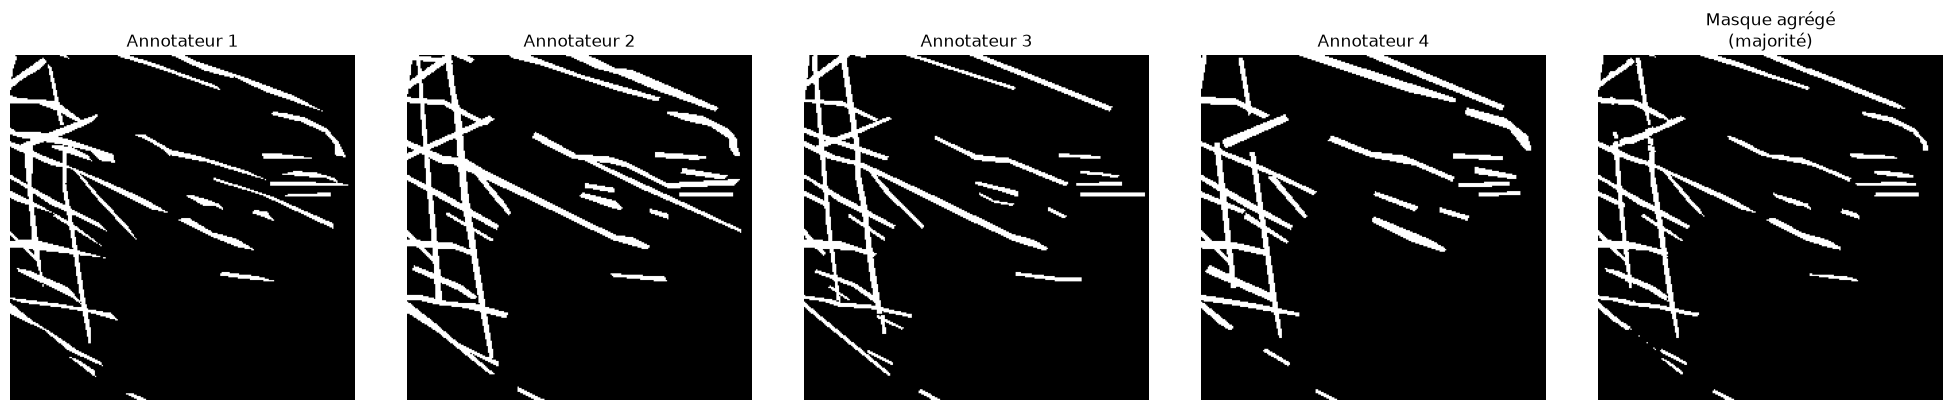

In [11]:
fig, axes = plt.subplots(1, n_annotators + 1, figsize=(4 * (n_annotators + 1), 4))

for a in range(n_annotators):
    axes[a].imshow(individual_masks[:, :, a], cmap="gray")
    axes[a].set_title(f"Annotateur {a + 1}")
    axes[a].axis("off")

axes[-1].imshow(mask_agg, cmap="gray")
axes[-1].set_title("Masque agrégé\n(majorité)")
axes[-1].axis("off")

plt.tight_layout()
plt.show()

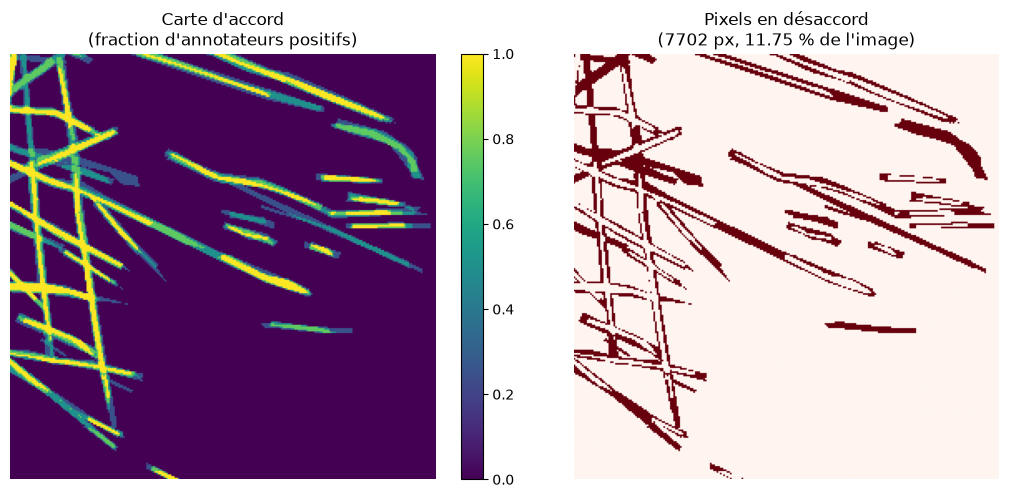

In [12]:
# Carte d'accord : fraction d'annotateurs ayant marqué chaque pixel comme contrail
agreement_map = individual_masks.mean(axis=-1)
disagreement_mask = (agreement_map > 0) & (agreement_map < 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

im0 = axes[0].imshow(agreement_map, cmap="viridis", vmin=0, vmax=1)
axes[0].set_title("Carte d'accord\n(fraction d'annotateurs positifs)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

axes[1].imshow(disagreement_mask, cmap="Reds")
axes[1].set_title(f"Pixels en désaccord\n({disagreement_mask.sum()} px, {disagreement_mask.mean() * 100:.2f} % de l'image)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [13]:
# Accord par paire d'annotateurs, mesuré en IoU


def iou(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    mask_a, mask_b = mask_a.astype(bool), mask_b.astype(bool)
    union = np.logical_or(mask_a, mask_b).sum()
    if union == 0:
        return 1.0
    return np.logical_and(mask_a, mask_b).sum() / union


pairwise_iou = np.array(
    [[iou(individual_masks[:, :, i], individual_masks[:, :, j]) for j in range(n_annotators)] for i in range(n_annotators)]
)

iou_df = pd.DataFrame(
    pairwise_iou,
    index=[f"A{i + 1}" for i in range(n_annotators)],
    columns=[f"A{i + 1}" for i in range(n_annotators)],
)
print(iou_df.round(3))

off_diag = pairwise_iou[~np.eye(n_annotators, dtype=bool)]
print(f"\nIoU moyen entre paires d'annotateurs (hors diagonale) : {off_diag.mean():.3f}")

       A1     A2     A3     A4
A1  1.000  0.527  0.528  0.517
A2  0.527  1.000  0.566  0.556
A3  0.528  0.566  1.000  0.505
A4  0.517  0.556  0.505  1.000

IoU moyen entre paires d'annotateurs (hors diagonale) : 0.533


## Représentation Ash RGB (fausse couleur multi-bandes)

Jusqu'ici seule la bande 13 (10.3 µm) a été affichée en niveaux de gris. Le schéma **Ash RGB**, standard pour GOES-16 ABI et utilisé par la communauté OpenContrails, combine les bandes 11, 13, 14 et 15 pour faire ressortir les nuages de glace fins (dont les contrails) par rapport au fond :

- **Rouge** = différence de température de brillance band15 − band13
- **Vert** = différence de température de brillance band14 − band11
- **Bleu** = température de brillance band13 (brute)

Chaque canal est normalisé sur une plage physique typique puis saturé dans [0, 1].

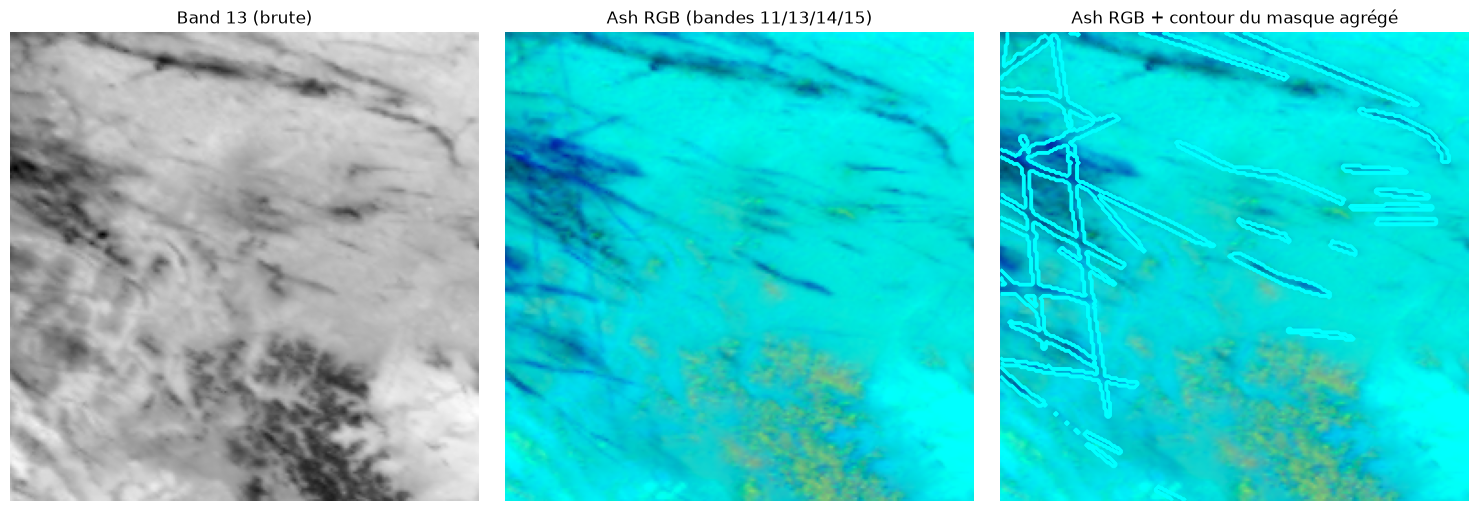

In [14]:
_T13_BOUNDS = (243, 303)
_CLOUD_TOP_TDIFF_BOUNDS = (-4, 5)
_TDIFF_BOUNDS = (-4, 2)


def normalize_range(data: np.ndarray, bounds: tuple[float, float]) -> np.ndarray:
    return (data - bounds[0]) / (bounds[1] - bounds[0])


def ash_color_scheme(band11: np.ndarray, band13: np.ndarray, band14: np.ndarray, band15: np.ndarray) -> np.ndarray:
    r = normalize_range(band15 - band13, _TDIFF_BOUNDS)
    g = normalize_range(band14 - band11, _CLOUD_TOP_TDIFF_BOUNDS)
    b = normalize_range(band13, _T13_BOUNDS)
    return np.clip(np.stack([r, g, b], axis=-1), 0, 1)


band11 = np.load(disagreement_record_dir / "band_11.npy")
band13_disagreement = np.load(disagreement_record_dir / "band_13.npy")
band14 = np.load(disagreement_record_dir / "band_14.npy")
band15 = np.load(disagreement_record_dir / "band_15.npy")

ash_target = ash_color_scheme(
    band11[:, :, TARGET_FRAME],
    band13_disagreement[:, :, TARGET_FRAME],
    band14[:, :, TARGET_FRAME],
    band15[:, :, TARGET_FRAME],
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(band13_disagreement[:, :, TARGET_FRAME], cmap="gray")
axes[0].set_title("Band 13 (brute)")
axes[0].axis("off")

axes[1].imshow(ash_target)
axes[1].set_title("Ash RGB (bandes 11/13/14/15)")
axes[1].axis("off")

axes[2].imshow(ash_target)
axes[2].contour(mask_agg, colors="cyan", linewidths=1.5)
axes[2].set_title("Ash RGB + contour du masque agrégé")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Bilan de la Phase 1

- **Dimensions** : les 9 bandes (`band_08` à `band_16`) ont toutes la forme `(256, 256, 8)` (H, W, T) sur tous les records inspectés ; `human_pixel_masks` est `(256, 256, 1)` ; `human_individual_masks` est `(256, 256, 1, n_annotateurs)` avec `n_annotateurs` variable (4 à 6 selon le record). La frame cible est toujours l'indice `TARGET_FRAME = 4` (4 frames avant, 3 après).
- **Déséquilibre de classe** : confirmé — plusieurs records n'ont aucun pixel positif, et parmi ceux qui en ont, la fraction de pixels contrail reste très faible (< 10 %). À garder en tête pour le choix de la loss (BCE + Dice, éventuellement Focal) en Phase 2.
- **Désaccord entre annotateurs** : mesurable et non négligeable (IoU par paire < 1, pixels de bord en désaccord). C'est la base nécessaire pour une piste *uncertainty-aware* ultérieure (Phase 4).
- **Ash RGB** : représentation multi-bandes implémentée et comparée à la bande brute ; à réutiliser comme entrée possible du modèle en Phase 2, en alternative à un simple stack de bandes.

Prochaine étape : Phase 2 — baseline U-Net (notebook `02_baseline_results.ipynb`), avec le loader de données (`src/data/`), le split train/val, la boucle d'entraînement et les métriques Dice/IoU/Precision/Recall.